In [31]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [32]:
df=pd.read_csv("height-weight.csv")

In [33]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [34]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [35]:
df.shape

(23, 2)

In [36]:
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [37]:
df.dtypes

Weight    int64
Height    int64
dtype: object

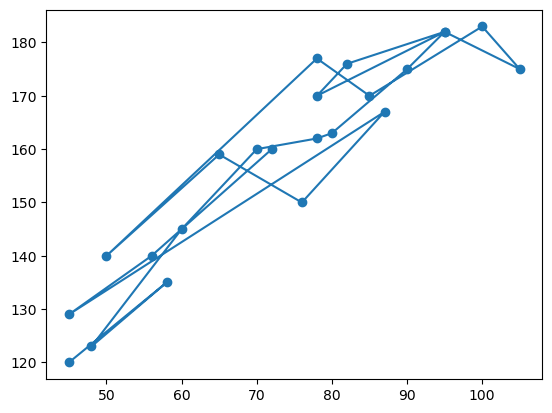

In [38]:
plt.scatter(df["Weight"],df["Height"])
plt.plot(df["Weight"],df["Height"])

In [39]:
X=df[['Weight']]
y=df["Height"]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.33, random_state=42)

In [42]:
X_train.shape,X_test.shape

((15, 1), (8, 1))

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()



In [44]:
X_train=scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [47]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
y_pred=model.predict(x_test)
y_pred

array([162.8051967 , 162.8051967 , 128.40340121, 180.52733377,
       149.25297424, 190.95212028, 141.95562368, 185.73972703])

In [50]:
y_test

15    177
9     170
0     120
8     182
17    159
12    175
1     135
13    183
Name: Height, dtype: int64

In [52]:
model.coef_
model.intercept_

np.float64(156.13333333333333)

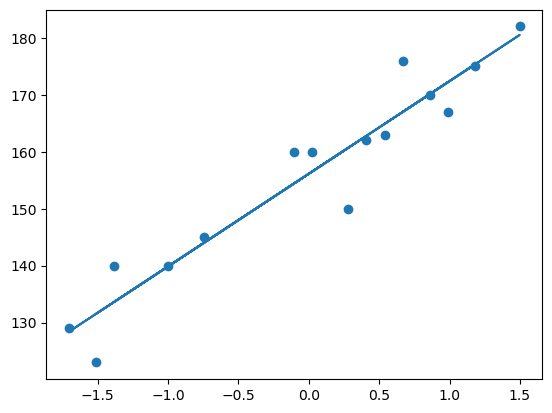

In [58]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train))

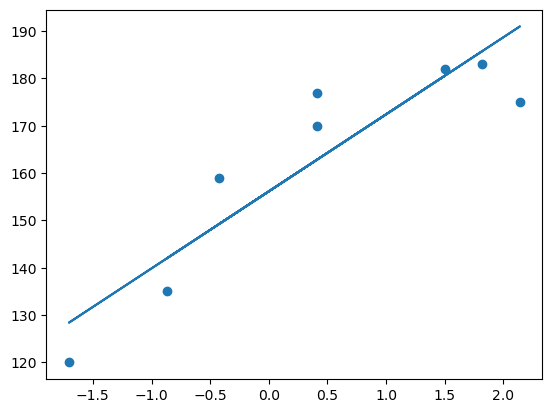

In [60]:
plt.scatter(x_test,y_test)
plt.plot(x_test,model.predict(x_test))

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error

In [67]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

In [71]:
mae,mse,rmse

(8.332521348806658, 91.4256238324171, np.float64(9.561674739940546))

In [72]:
from sklearn.metrics import r2_score

In [75]:
accuracy=r2_score(y_test,y_pred)
accuracy*100

80.74173081896227

In [76]:
adj_r2=1-(1-accuracy)*(len(y_test))/(len(y_test)-x_test.shape[1]-1)

In [77]:
adj_r2

0.7432230775861635

In [78]:
residuals=y_test-y_pred

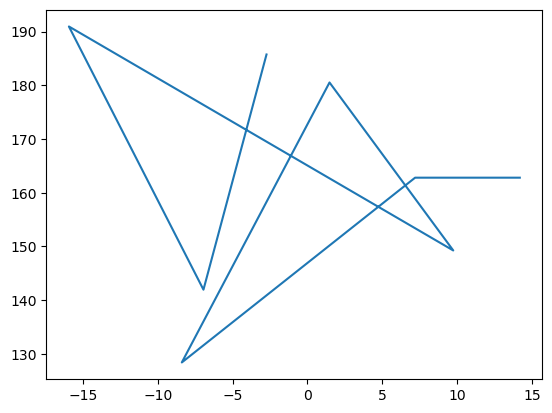

In [ ]:
plt.plot(residuals,y_pred)